In [1]:
# ============================================
# CYCLISTIC BIKE SHARE ANALYSIS
# Step 2: Load and Explore Data
# ============================================

# Import our tools (like opening a toolbox)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Tell Python where your file is
# ⚠️ CHANGE THIS PATH to where YOUR csv file is saved!
df = pd.read_csv('../data/202512-divvy-tripdata.csv')

# Show basic info
print("✅ File loaded successfully!")
print(f"📊 Total Rides: {len(df):,}")
print(f"📋 Total Columns: {len(df.columns)}")
print()
print("🔍 Column Names:")
for col in df.columns:
    print(f"   → {col}")

✅ File loaded successfully!
📊 Total Rides: 140,534
📋 Total Columns: 13

🔍 Column Names:
   → ride_id
   → rideable_type
   → started_at
   → ended_at
   → start_station_name
   → start_station_id
   → end_station_name
   → end_station_id
   → start_lat
   → start_lng
   → end_lat
   → end_lng
   → member_casual


In [2]:
# ============================================
# Check for missing values and data types
# ============================================

print("⚠️ MISSING VALUES:")
print(df.isnull().sum())
print()
print("📝 DATA TYPES:")
print(df.dtypes)
print()
print("👥 MEMBER vs CASUAL COUNT:")
print(df['member_casual'].value_counts())
print()
print("🚲 BIKE TYPES:")
print(df['rideable_type'].value_counts())

⚠️ MISSING VALUES:
ride_id                   0
rideable_type             0
started_at                0
ended_at                  0
start_station_name    26926
start_station_id      26926
end_station_name      30045
end_station_id        30045
start_lat                 0
start_lng                 0
end_lat                 122
end_lng                 122
member_casual             0
dtype: int64

📝 DATA TYPES:
ride_id                   str
rideable_type             str
started_at                str
ended_at                  str
start_station_name        str
start_station_id          str
end_station_name          str
end_station_id            str
start_lat             float64
start_lng             float64
end_lat               float64
end_lng               float64
member_casual             str
dtype: object

👥 MEMBER vs CASUAL COUNT:
member_casual
member    112454
casual     28080
Name: count, dtype: int64

🚲 BIKE TYPES:
rideable_type
electric_bike    95674
classic_bike     44860
Name: cou

In [3]:
# ============================================
# STEP 3A: Fix the date columns
# ============================================

# Convert text dates to REAL dates Python understands
df['started_at'] = pd.to_datetime(df['started_at'])
df['ended_at'] = pd.to_datetime(df['ended_at'])

print("✅ Dates fixed!")
print(f"   started_at type is now: {df['started_at'].dtype}")
print(f"   ended_at type is now:   {df['ended_at'].dtype}")

✅ Dates fixed!
   started_at type is now: datetime64[us]
   ended_at type is now:   datetime64[us]


In [4]:
# ============================================
# STEP 3B: Add ride_length column (in minutes)
# ============================================

# Subtract start time from end time = duration
df['ride_length'] = (df['ended_at'] - df['started_at']).dt.total_seconds() / 60

print("✅ ride_length column added!")
print()
print("⏱️ Ride Length Stats (in minutes):")
print(f"   Shortest ride : {df['ride_length'].min():.1f} mins")
print(f"   Longest ride  : {df['ride_length'].max():.1f} mins")
print(f"   Average ride  : {df['ride_length'].mean():.1f} mins")

✅ ride_length column added!

⏱️ Ride Length Stats (in minutes):
   Shortest ride : 0.0 mins
   Longest ride  : 1500.0 mins
   Average ride  : 12.9 mins


In [5]:
# ============================================
# STEP 3C: Add day_of_week and day_name columns
# ============================================

# Add day name (Monday, Tuesday etc.)
df['day_name'] = df['started_at'].dt.day_name()

# Add day number (1=Sunday, 7=Saturday like the case study says)
df['day_of_week'] = df['started_at'].dt.dayofweek.map({
    6:1,  # Sunday = 1
    0:2,  # Monday = 2
    1:3,  # Tuesday = 3
    2:4,  # Wednesday = 4
    3:5,  # Thursday = 5
    4:6,  # Friday = 6
    5:7   # Saturday = 7
})

# Add hour of day (0-23)
df['hour'] = df['started_at'].dt.hour

# Add month
df['month'] = df['started_at'].dt.month

print("✅ New columns added!")
print()
print("📅 Rides by Day:")
print(df['day_name'].value_counts())

✅ New columns added!

📅 Rides by Day:
day_name
Tuesday      27553
Wednesday    25551
Monday       20956
Thursday     19979
Friday       19894
Saturday     17211
Sunday        9390
Name: count, dtype: int64


In [6]:
# ============================================
# STEP 3D: Remove bad/dirty rides
# ============================================

before = len(df)

# Remove rides with 0 or negative duration (impossible!)
df = df[df['ride_length'] > 0]

# Remove rides over 24 hours (1440 mins) — probably errors
df = df[df['ride_length'] <= 1440]

after = len(df)

print("🗑️ CLEANING RESULTS:")
print(f"   Rides BEFORE cleaning : {before:,}")
print(f"   Bad rides removed     : {before - after:,}")
print(f"   Rides AFTER cleaning  : {after:,}")
print()
print("✅ Data is now clean!")

🗑️ CLEANING RESULTS:
   Rides BEFORE cleaning : 140,534
   Bad rides removed     : 125
   Rides AFTER cleaning  : 140,409

✅ Data is now clean!


In [9]:
# ============================================
# STEP 3E: Save clean data to outputs folder
# ============================================

import os

# This creates the outputs folder automatically if it doesn't exist!
os.makedirs('../outputs', exist_ok=True)

# Now save the file
df.to_csv('../outputs/clean_tripdata.csv', index=False)

print("✅ Clean file saved to outputs folder!")
print()
print("📋 Your clean data now has these columns:")
for col in df.columns:
    print(f"   → {col}")
print()
print(f"📊 Total clean rides ready for analysis: {len(df):,}")

✅ Clean file saved to outputs folder!

📋 Your clean data now has these columns:
   → ride_id
   → rideable_type
   → started_at
   → ended_at
   → start_station_name
   → start_station_id
   → end_station_name
   → end_station_id
   → start_lat
   → start_lng
   → end_lat
   → end_lng
   → member_casual
   → ride_length
   → day_name
   → day_of_week
   → hour
   → month

📊 Total clean rides ready for analysis: 140,409


In [10]:
# ============================================
# STEP 4: ANALYZE — Load Clean Data
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the clean file we saved
df = pd.read_csv('../outputs/clean_tripdata.csv')

print("✅ Clean data loaded!")
print(f"📊 Total rides: {len(df):,}")
print()

# Quick summary
print("👥 MEMBER vs CASUAL:")
counts = df['member_casual'].value_counts()
for rider_type, count in counts.items():
    pct = count/len(df)*100
    print(f"   {rider_type}: {count:,} rides ({pct:.1f}%)")

✅ Clean data loaded!
📊 Total rides: 140,409

👥 MEMBER vs CASUAL:
   member: 112,415 rides (80.1%)
   casual: 27,994 rides (19.9%)


In [11]:
# ============================================
# ANALYSIS 1: Who rides LONGER?
# ============================================

ride_stats = df.groupby('member_casual')['ride_length'].agg([
    'mean', 'median', 'max', 'count'
]).round(2)

print("⏱️ RIDE LENGTH STATS (in minutes):")
print()
print(f"{'':15} {'CASUAL':>10} {'MEMBER':>10}")
print(f"{'─'*35}")
print(f"{'Average ride':15} {ride_stats.loc['casual','mean']:>10.1f} {ride_stats.loc['member','mean']:>10.1f}")
print(f"{'Median ride':15} {ride_stats.loc['casual','median']:>10.1f} {ride_stats.loc['member','median']:>10.1f}")
print(f"{'Longest ride':15} {ride_stats.loc['casual','max']:>10.1f} {ride_stats.loc['member','max']:>10.1f}")
print(f"{'Total rides':15} {ride_stats.loc['casual','count']:>10,.0f} {ride_stats.loc['member','count']:>10,.0f}")
print()
print("💡 INSIGHT: Whoever has higher average = rides for LEISURE")
print("           Whoever has lower average  = rides for COMMUTE")

⏱️ RIDE LENGTH STATS (in minutes):

                    CASUAL     MEMBER
───────────────────────────────────
Average ride          12.4       11.4
Median ride            7.4        7.3
Longest ride        1431.3     1418.2
Total rides         27,994    112,415

💡 INSIGHT: Whoever has higher average = rides for LEISURE
           Whoever has lower average  = rides for COMMUTE


In [12]:
# ============================================
# ANALYSIS 2: WHAT DAY do they ride?
# ============================================

# Order days correctly
day_order = ['Sunday','Monday','Tuesday','Wednesday','Thursday','Friday','Saturday']

day_counts = df.groupby(['day_name','member_casual']).size().reset_index(name='rides')

print("📅 RIDES BY DAY OF WEEK:")
print()
print(f"{'Day':12} {'Casual':>8} {'Member':>8} {'Total':>8}")
print(f"{'─'*40}")

for day in day_order:
    casual = day_counts[(day_counts['day_name']==day) & 
                       (day_counts['member_casual']=='casual')]['rides'].values
    member = day_counts[(day_counts['day_name']==day) & 
                       (day_counts['member_casual']=='member')]['rides'].values
    
    c = casual[0] if len(casual)>0 else 0
    m = member[0] if len(member)>0 else 0
    print(f"{day:12} {c:>8,} {m:>8,} {c+m:>8,}")

print()
print("💡 INSIGHT: More weekend rides = leisure riders")
print("           More weekday rides = commuters")

📅 RIDES BY DAY OF WEEK:

Day            Casual   Member    Total
────────────────────────────────────────
Sunday          2,270    7,100    9,370
Monday          3,375   17,564   20,939
Tuesday         4,922   22,609   27,531
Wednesday       4,582   20,960   25,542
Thursday        3,753   16,209   19,962
Friday          4,196   15,679   19,875
Saturday        4,896   12,294   17,190

💡 INSIGHT: More weekend rides = leisure riders
           More weekday rides = commuters


In [13]:
# ============================================
# ANALYSIS 3: WHAT TIME do they ride?
# ============================================

hour_counts = df.groupby(['hour','member_casual']).size().reset_index(name='rides')

print("🕐 PEAK RIDING HOURS:")
print()

for rider in ['casual', 'member']:
    data = hour_counts[hour_counts['member_casual']==rider]
    top3 = data.nlargest(3, 'rides')
    print(f"  {rider.upper()} top hours:")
    for _, row in top3.iterrows():
        hour = int(row['hour'])
        am_pm = 'AM' if hour < 12 else 'PM'
        hour_12 = hour if hour <= 12 else hour - 12
        if hour_12 == 0: hour_12 = 12
        print(f"    → {hour_12}:00 {am_pm} — {int(row['rides']):,} rides")
    print()

print("💡 INSIGHT: 8AM & 5PM peaks = commuters (members)")
print("           Midday peaks    = leisure (casuals)")

🕐 PEAK RIDING HOURS:

  CASUAL top hours:
    → 4:00 PM — 2,528 rides
    → 5:00 PM — 2,394 rides
    → 3:00 PM — 2,267 rides

  MEMBER top hours:
    → 5:00 PM — 11,268 rides
    → 4:00 PM — 10,991 rides
    → 8:00 AM — 8,458 rides

💡 INSIGHT: 8AM & 5PM peaks = commuters (members)
           Midday peaks    = leisure (casuals)


In [14]:
# ============================================
# ANALYSIS 4: WHAT BIKE do they prefer?
# ============================================

bike_counts = df.groupby(['member_casual','rideable_type']).size().reset_index(name='rides')

print("🚲 BIKE TYPE PREFERENCE:")
print()

for rider in ['casual', 'member']:
    data = bike_counts[bike_counts['member_casual']==rider]
    total = data['rides'].sum()
    print(f"  {rider.upper()}:")
    for _, row in data.iterrows():
        pct = row['rides']/total*100
        print(f"    → {row['rideable_type']:15} {row['rides']:>8,} rides ({pct:.1f}%)")
    print()

print("💡 INSIGHT: Electric bike preference shows who wants")
print("           convenience vs exercise!")

🚲 BIKE TYPE PREFERENCE:

  CASUAL:
    → classic_bike       6,951 rides (24.8%)
    → electric_bike     21,043 rides (75.2%)

  MEMBER:
    → classic_bike      37,784 rides (33.6%)
    → electric_bike     74,631 rides (66.4%)

💡 INSIGHT: Electric bike preference shows who wants
           convenience vs exercise!


In [15]:
# ============================================
# Save Summary for later use
# ============================================

import os
os.makedirs('../outputs', exist_ok=True)

# Save ride stats by member type
summary = df.groupby('member_casual').agg(
    total_rides    = ('ride_id','count'),
    avg_ride_mins  = ('ride_length','mean'),
    median_ride    = ('ride_length','median'),
).round(2)

summary.to_csv('../outputs/analysis_summary.csv')
print("✅ Analysis summary saved!")
print()
print(summary)

✅ Analysis summary saved!

               total_rides  avg_ride_mins  median_ride
member_casual                                         
casual               27994          12.42         7.43
member              112415          11.37         7.29


In [16]:
# ============================================
# STEP 5: SHARE — Create Visualizations
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load clean data
df = pd.read_csv('../outputs/clean_tripdata.csv')

# Set beautiful style for ALL charts
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette(['#FF6B6B', '#4ECDC4'])  # Red=Casual, Teal=Member

# Create folder for charts
os.makedirs('../outputs/charts', exist_ok=True)

print("✅ Chart style set!")
print("📁 Charts will be saved to: outputs/charts/")

✅ Chart style set!
📁 Charts will be saved to: outputs/charts/


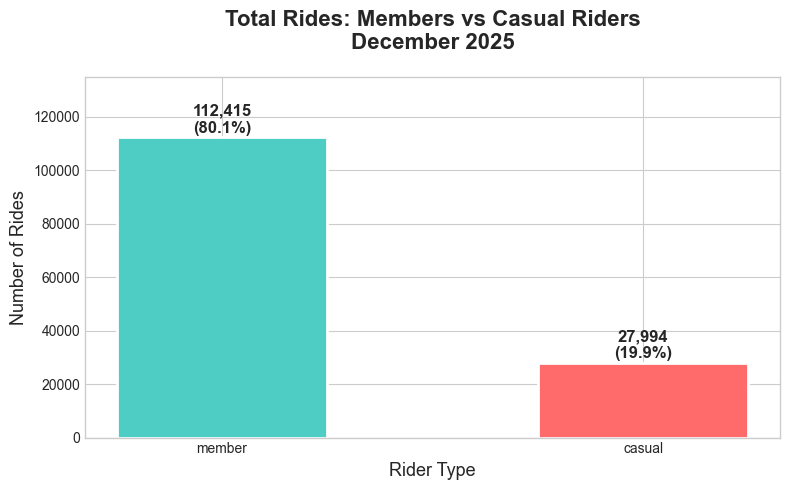

✅ Chart 1 saved!


In [17]:
# ============================================
# CHART 1: Total Rides — Member vs Casual
# ============================================

fig, ax = plt.subplots(figsize=(8, 5))

# Count rides per type
counts = df['member_casual'].value_counts()
colors = ['#4ECDC4', '#FF6B6B']  # Teal=member, Red=casual

bars = ax.bar(counts.index, counts.values, 
              color=colors, width=0.5, edgecolor='white', linewidth=2)

# Add number labels ON TOP of bars
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{val:,}\n({val/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

# Labels and title
ax.set_title('Total Rides: Members vs Casual Riders\nDecember 2025', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Rider Type', fontsize=13)
ax.set_ylabel('Number of Rides', fontsize=13)
ax.set_ylim(0, max(counts.values) * 1.2)

plt.tight_layout()
plt.savefig('../outputs/charts/chart1_total_rides.png', dpi=150)
plt.show()
print("✅ Chart 1 saved!")

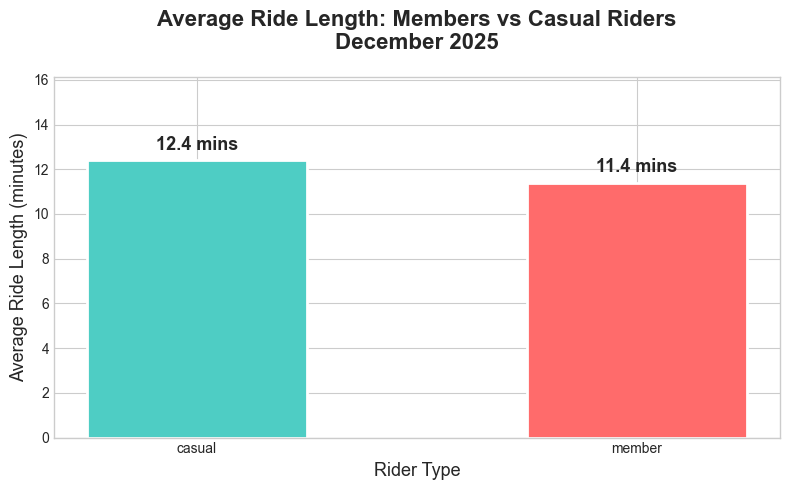

✅ Chart 2 saved!


In [18]:
# ============================================
# CHART 2: Average Ride Length Comparison
# ============================================

fig, ax = plt.subplots(figsize=(8, 5))

avg_ride = df.groupby('member_casual')['ride_length'].mean().round(1)
colors = ['#4ECDC4', '#FF6B6B']

bars = ax.bar(avg_ride.index, avg_ride.values,
              color=colors, width=0.5, edgecolor='white', linewidth=2)

# Add labels on bars
for bar, val in zip(bars, avg_ride.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val} mins',
            ha='center', va='bottom', fontsize=13, fontweight='bold')

ax.set_title('Average Ride Length: Members vs Casual Riders\nDecember 2025',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Rider Type', fontsize=13)
ax.set_ylabel('Average Ride Length (minutes)', fontsize=13)
ax.set_ylim(0, max(avg_ride.values) * 1.3)

plt.tight_layout()
plt.savefig('../outputs/charts/chart2_avg_ride_length.png', dpi=150)
plt.show()
print("✅ Chart 2 saved!")

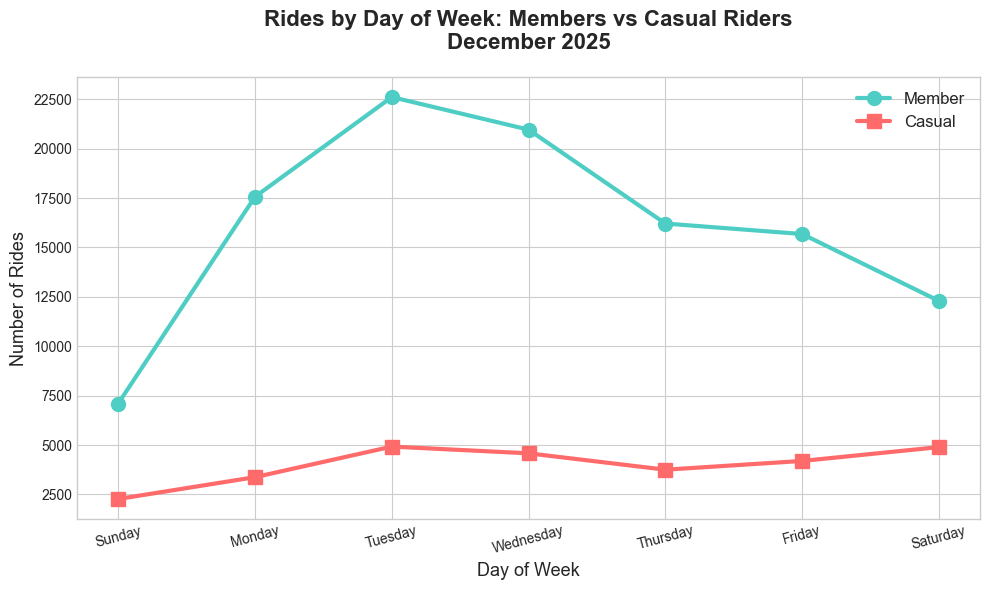

✅ Chart 3 saved!


In [19]:
# ============================================
# CHART 3: Rides by Day of Week
# ============================================

fig, ax = plt.subplots(figsize=(10, 6))

day_order = ['Sunday','Monday','Tuesday','Wednesday','Thursday','Friday','Saturday']

day_data = df.groupby(['day_name','member_casual']).size().reset_index(name='rides')

# Plot each rider type as separate line
for rider, color, marker in [('member','#4ECDC4','o'), ('casual','#FF6B6B','s')]:
    data = day_data[day_data['member_casual']==rider]
    data = data.set_index('day_name').reindex(day_order).reset_index()
    ax.plot(data['day_name'], data['rides'], 
            color=color, marker=marker, linewidth=3,
            markersize=10, label=rider.capitalize())

ax.set_title('Rides by Day of Week: Members vs Casual Riders\nDecember 2025',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Day of Week', fontsize=13)
ax.set_ylabel('Number of Rides', fontsize=13)
ax.legend(fontsize=12)
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../outputs/charts/chart3_rides_by_day.png', dpi=150)
plt.show()
print("✅ Chart 3 saved!")

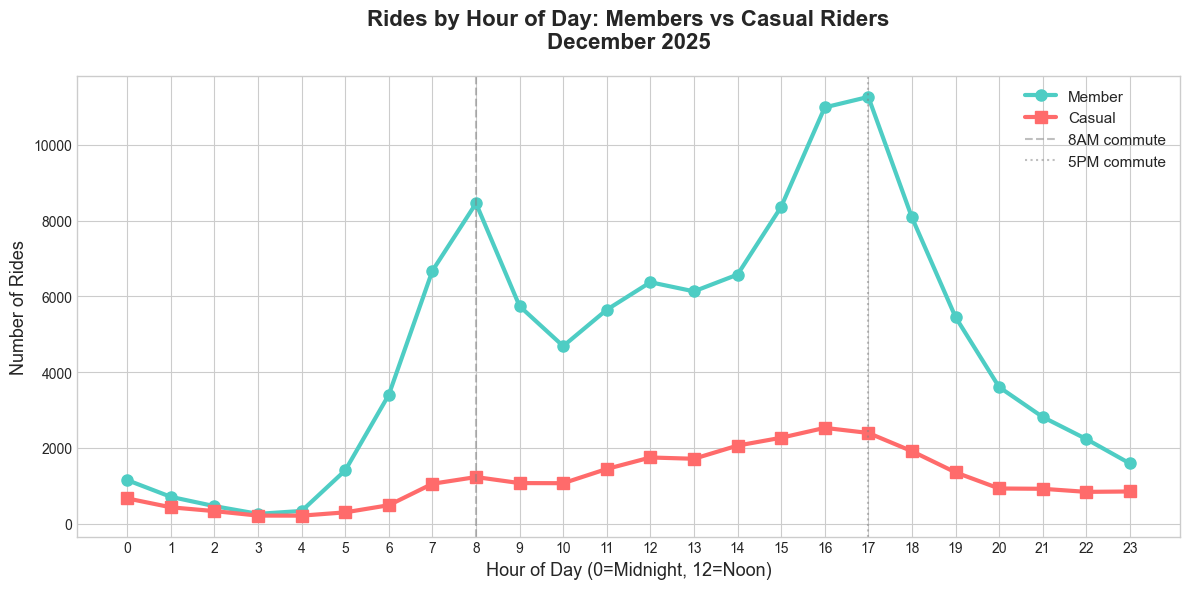

✅ Chart 4 saved!


In [20]:
# ============================================
# CHART 4: Rides by Hour of Day
# ============================================

fig, ax = plt.subplots(figsize=(12, 6))

hour_data = df.groupby(['hour','member_casual']).size().reset_index(name='rides')

for rider, color, marker in [('member','#4ECDC4','o'), ('casual','#FF6B6B','s')]:
    data = hour_data[hour_data['member_casual']==rider]
    ax.plot(data['hour'], data['rides'],
            color=color, marker=marker, linewidth=3,
            markersize=8, label=rider.capitalize())

# Mark commute hours
ax.axvline(x=8,  color='gray', linestyle='--', alpha=0.5, label='8AM commute')
ax.axvline(x=17, color='gray', linestyle=':',  alpha=0.5, label='5PM commute')

ax.set_title('Rides by Hour of Day: Members vs Casual Riders\nDecember 2025',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Hour of Day (0=Midnight, 12=Noon)', fontsize=13)
ax.set_ylabel('Number of Rides', fontsize=13)
ax.set_xticks(range(0, 24))
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('../outputs/charts/chart4_rides_by_hour.png', dpi=150)
plt.show()
print("✅ Chart 4 saved!")

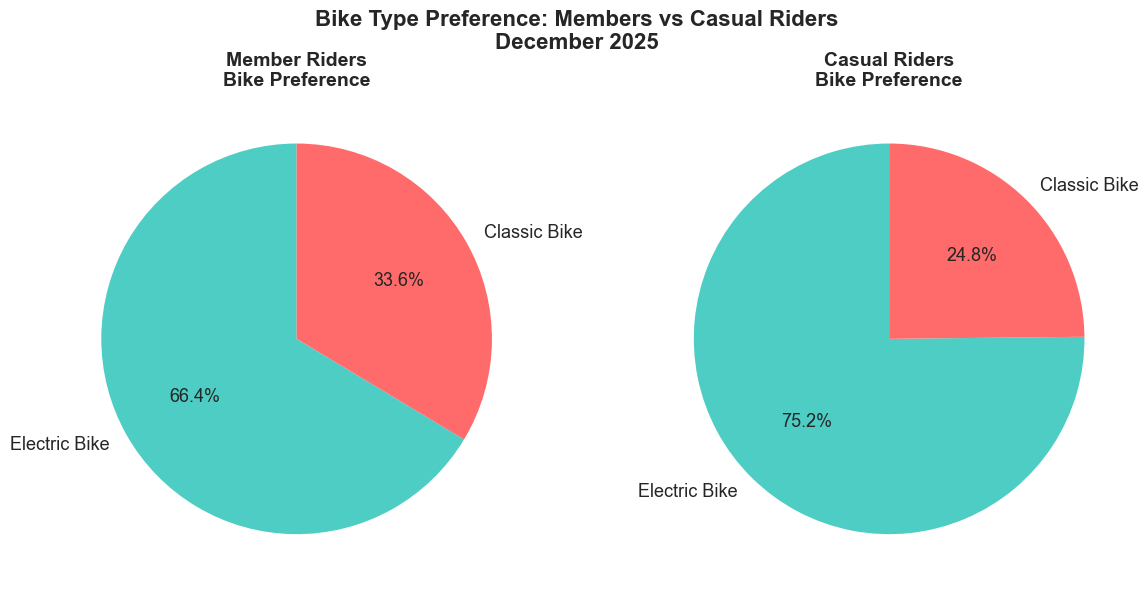

✅ Chart 5 saved!


In [21]:
# ============================================
# CHART 5: Bike Type Preference
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

colors = ['#4ECDC4', '#FF6B6B']

for idx, rider in enumerate(['member', 'casual']):
    data = df[df['member_casual']==rider]['rideable_type'].value_counts()
    axes[idx].pie(data.values,
                  labels=[x.replace('_',' ').title() for x in data.index],
                  colors=colors,
                  autopct='%1.1f%%',
                  startangle=90,
                  textprops={'fontsize': 13})
    axes[idx].set_title(f'{rider.capitalize()} Riders\nBike Preference',
                        fontsize=14, fontweight='bold')

fig.suptitle('Bike Type Preference: Members vs Casual Riders\nDecember 2025',
             fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/charts/chart5_bike_type.png', dpi=150)
plt.show()
print("✅ Chart 5 saved!")

In [22]:
# ============================================
# Check all charts are saved
# ============================================

import os

charts = os.listdir('../outputs/charts/')
print("📁 Charts saved in outputs/charts/:")
for chart in sorted(charts):
    print(f"   ✅ {chart}")

print()
print("🎉 ALL CHARTS COMPLETE!")
print("📂 Go to your PROJECT/outputs/charts/ folder to see them!")

📁 Charts saved in outputs/charts/:
   ✅ chart1_total_rides.png
   ✅ chart2_avg_ride_length.png
   ✅ chart3_rides_by_day.png
   ✅ chart4_rides_by_hour.png
   ✅ chart5_bike_type.png

🎉 ALL CHARTS COMPLETE!
📂 Go to your PROJECT/outputs/charts/ folder to see them!


In [23]:
# ============================================
# Export data for Power BI
# ============================================

import pandas as pd
import os

df = pd.read_csv('../outputs/clean_tripdata.csv')

# Create a lean version for Power BI (faster to load)
powerbi_df = df[[
    'ride_id',
    'rideable_type', 
    'member_casual',
    'ride_length',
    'day_name',
    'day_of_week',
    'hour',
    'start_station_name',
    'end_station_name'
]].copy()

# Save it
os.makedirs('../dashboard', exist_ok=True)
powerbi_df.to_csv('../dashboard/powerbi_data.csv', index=False)

print("✅ Power BI data file saved!")
print(f"📊 Rows exported: {len(powerbi_df):,}")
print(f"📋 Columns: {list(powerbi_df.columns)}")
print()
print("📂 File location: PROJECT/dashboard/powerbi_data.csv")

✅ Power BI data file saved!
📊 Rows exported: 140,409
📋 Columns: ['ride_id', 'rideable_type', 'member_casual', 'ride_length', 'day_name', 'day_of_week', 'hour', 'start_station_name', 'end_station_name']

📂 File location: PROJECT/dashboard/powerbi_data.csv
